# FishAI Common Global Model Training (Colab + VS Code)

This notebook is Colab-style, but runs directly in VS Code Jupyter as well.

Flow: data load -> cleaning -> preprocessing -> multi-model training -> best model selection -> save artifacts.

In [19]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
import joblib

RANDOM_STATE = 42
BOAT_TYPE_TARGET = None  # Keep None for global model

NOTEBOOK_DIR = Path.cwd()

# Resolve project root robustly for VS Code + Colab runtimes
project_root_candidates = [
    NOTEBOOK_DIR,
    NOTEBOOK_DIR / 'model' / 'cost_prediction',
    Path('/content/final_year_research/model/cost_prediction'),
]
for parent in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    project_root_candidates.append(parent)

PROJECT_ROOT = None
for candidate in project_root_candidates:
    if (candidate / 'training_data').exists() or (candidate / 'models').exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = NOTEBOOK_DIR

MODEL_ROOT = PROJECT_ROOT / 'models'
DATA_CANDIDATES = [
    PROJECT_ROOT / 'training_data' / 'training_data_all.csv',
    PROJECT_ROOT / 'data' / 'training_candidates_export.csv',
]

print('Notebook dir:', NOTEBOOK_DIR)
print('Project root:', PROJECT_ROOT)

Notebook dir: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\colab
Project root: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction


In [20]:
def find_data_file(paths):
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError('No dataset found. Checked: ' + ', '.join(str(x) for x in paths))

def normalize_schema(df):
    rename_map = {}

    column_aliases = {
        'feature_distanceKm': 'distanceKm',
        'feature_speed': 'speed',
        'feature_engineHP': 'engineHP',
        'feature_fishingHours': 'fishingHours',
        'feature_weatherSeverityIndex': 'weatherSeverityIndex',
        'label_actualFuelLiters': 'fuelUsedLiters',
        'engineHorsePower': 'engineHP',
        'windSpeed': 'weatherSeverityIndex',
        'actualFuelLiters': 'fuelUsedLiters',
    }
    for source_name, target_name in column_aliases.items():
        if source_name in df.columns and target_name not in df.columns:
            rename_map[source_name] = target_name

    if rename_map:
        df = df.rename(columns=rename_map)
        print('Renamed columns:', rename_map)

    if 'speed' not in df.columns:
        df['speed'] = 10.0
    if 'fishingHours' not in df.columns:
        if 'tripDurationHours' in df.columns:
            df['fishingHours'] = df['tripDurationHours'].clip(lower=1)
        else:
            df['fishingHours'] = 8.0
    if 'distanceKm' not in df.columns:
        raise ValueError('distanceKm column is required')
    if 'engineHP' not in df.columns:
        raise ValueError('engineHP or engineHorsePower column is required')
    if 'weatherSeverityIndex' not in df.columns:
        df['weatherSeverityIndex'] = 0.2

    if 'fuelUsedLiters' not in df.columns:
        if 'actualFuelLiters' in df.columns:
            df['fuelUsedLiters'] = df['actualFuelLiters']
        else:
            raise ValueError('fuelUsedLiters or actualFuelLiters column is required as label')

    return df

data_file = find_data_file(DATA_CANDIDATES)
df = pd.read_csv(data_file)
df = normalize_schema(df)

print('Dataset selected:', data_file)
print('Shape before filtering:', df.shape)
df.head()

Dataset selected: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\trips_export.csv
Shape before filtering: (2000, 18)


,tripDate,distanceKm,engineHorsePower,tripDurationHours,windSpeed,waveHeight,fuelPricePerLiter,crewSize,maintenanceCost,iceCost,foodCost,riskFactor,fuelUsedLiters,totalCost,engineHP,weatherSeverityIndex,speed,fishingHours
0,2025-05-21,35.472789,120,2.065400,6.636163,0.105270,1.407647,3,9.027748,9.761806,10.127981,0.065061,17.40,215.95,120,6.636163,10.0,2.065400
1,2025-09-29,37.851474,80,1.978098,2.929704,0.000000,1.970188,6,8.298246,8.441619,6.599289,0.025166,11.79,356.74,80,2.929704,10.0,1.978098
2,2025-11-30,109.196698,150,6.848244,4.145293,0.699198,1.517717,4,20.111607,10.023796,10.443670,0.066240,69.92,362.02,150,4.145293,10.0,6.848244
3,2025-07-20,65.725996,100,4.693619,4.885385,0.128399,1.312369,5,11.631448,10.974939,15.469220,0.043036,25.13,329.84,100,4.885385,10.0,4.693619
4,2025-04-21,118.047300,150,7.788771,6.281684,0.701255,1.669953,6,13.169327,11.683250,6.194809,0.070700,86.86,508.47,150,6.281684,10.0,7.788771


In [21]:
FEATURES = ['distanceKm', 'speed', 'engineHP', 'fishingHours', 'weatherSeverityIndex']
TARGET = 'fuelUsedLiters'

for c in FEATURES + [TARGET]:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna(subset=FEATURES + [TARGET]).copy()

q1 = df[TARGET].quantile(0.25)
q3 = df[TARGET].quantile(0.75)
iqr = q3 - q1
low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr
df = df[(df[TARGET] >= low) & (df[TARGET] <= high)].copy()

if df.empty:
    raise ValueError(f'No rows left after cleaning from {data_file}.')

MIN_ROWS_FOR_TRAINING = 10
if len(df) < MIN_ROWS_FOR_TRAINING:
    raise ValueError(
        f'Insufficient data for global model: only {len(df)} row(s) remain after cleaning from {data_file}. '
        f'Need at least {MIN_ROWS_FOR_TRAINING} rows to train and evaluate safely.'
    )

print('Shape after cleaning:', df.shape)
df[FEATURES + [TARGET]].describe().T

Shape after cleaning: (1987, 18)


,count,mean,std,min,25%,50%,75%,max
distanceKm,1987.0,61.387692,32.970750,5.022409,33.285764,61.184751,90.126231,119.967087
speed,1987.0,10.000000,0.000000,10.000000,10.000000,10.000000,10.000000,10.000000
engineHP,1987.0,100.025164,34.039095,50.000000,80.000000,100.000000,120.000000,150.000000
fishingHours,1987.0,4.307708,2.446964,1.000000,2.171746,4.139149,6.043173,12.373852
weatherSeverityIndex,1987.0,4.957082,1.709109,0.465165,3.613386,4.967525,6.276437,9.413515
fuelUsedLiters,1987.0,26.671852,18.654819,1.000000,11.240000,22.560000,39.160000,81.870000


In [22]:
X = df[FEATURES]
y = df[TARGET]

training_mode = 'split'
test_size = 0.2 if len(df) >= 50 else 0.25
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=RANDOM_STATE
)

models = {
    'RandomForest': RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}

rows = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred)
    mape = np.mean(np.abs((y_test - pred) / np.maximum(np.abs(y_test), 1e-9))) * 100

    trained_models[name] = model
    rows.append({'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape})

metrics_df = pd.DataFrame(rows).sort_values('MAPE').reset_index(drop=True)
metrics_df

,model,MAE,RMSE,R2,MAPE
0,GradientBoosting,1.901551,2.374573,0.983818,16.417380
1,HistGradientBoosting,1.928422,2.450657,0.982764,17.035795
2,RandomForest,1.910894,2.407480,0.983366,17.274564
3,ExtraTrees,1.955710,2.442363,0.982880,18.201502


In [23]:
best_model_name = metrics_df.iloc[0]['model']
best_model = trained_models[best_model_name]

target_dir = MODEL_ROOT / 'fishtripcost' / 'global' / 'best_model'
target_dir.mkdir(parents=True, exist_ok=True)

model_file = target_dir / 'fuel_model.pkl'
meta_file = target_dir / 'metadata.json'

joblib.dump(best_model, model_file)

metadata = {
    'scope': 'GLOBAL',
    'boat_type': None,
    'dataset': str(data_file),
    'features': FEATURES,
    'target': TARGET,
    'selected_model': best_model_name,
    'ranking': metrics_df.to_dict(orient='records'),
    'training_mode': training_mode,
    'rows_used': int(len(df)),
}
meta_file.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

print('Saved model to:', model_file)
print('Saved metadata to:', meta_file)

Saved model to: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\models\fishtripcost\global\best_model\fuel_model.pkl
Saved metadata to: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\models\fishtripcost\global\best_model\metadata.json


In [24]:
sample = X_test.head(1)
pred = float(best_model.predict(sample)[0])
print('Sample input:')
print(sample)
print('Predicted fuel liters:', round(pred, 3))

Sample input:
     distanceKm  speed  engineHP  fishingHours  weatherSeverityIndex
214   28.649201   10.0        80      1.025592              3.788487
Predicted fuel liters: 9.128


In [25]:
import subprocess
import sys

# Install tensorflow in the current kernel environment
print("Installing TensorFlow...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tensorflow"])
print("TensorFlow installed successfully")

Installing TensorFlow...
TensorFlow installed successfully


In [26]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

# Check if we have enough data for neural network training
if len(X_train) < 5:
    print(f'Warning: Only {len(X_train)} training sample(s). Skipping neural network training (requires minimum 5 samples).')
    history = None
else:
    # Normalize features for neural network training
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Build neural network model
    nn_model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(len(FEATURES),)),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])

    nn_model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    # Determine validation split based on available data
    if len(X_train) < 10:
        validation_split = None
        # Train on all data without validation split
        history = nn_model.fit(
            X_train_scaled,
            y_train,
            epochs=25,
            batch_size=1,
            verbose=0
        )
        print('Neural Network Training Complete (all data used for training)')
        print('Best training MAE:', round(min(history.history['mae']), 3))
    else:
        validation_split = 0.2
        history = nn_model.fit(
            X_train_scaled,
            y_train,
            epochs=25,
            batch_size=8,
            validation_split=validation_split,
            verbose=0
        )
        print('Neural Network Training Complete')
        print('Best validation MAE:', round(min(history.history['val_mae']), 3))

C:\Users\Piuminda Jayaweera\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network Training Complete
Best validation MAE: 1.724


[Neural Network Evaluation]
  R² Score: 0.9812
  MAE: 2.04
  RMSE: 2.56
  MAPE: 20.40%


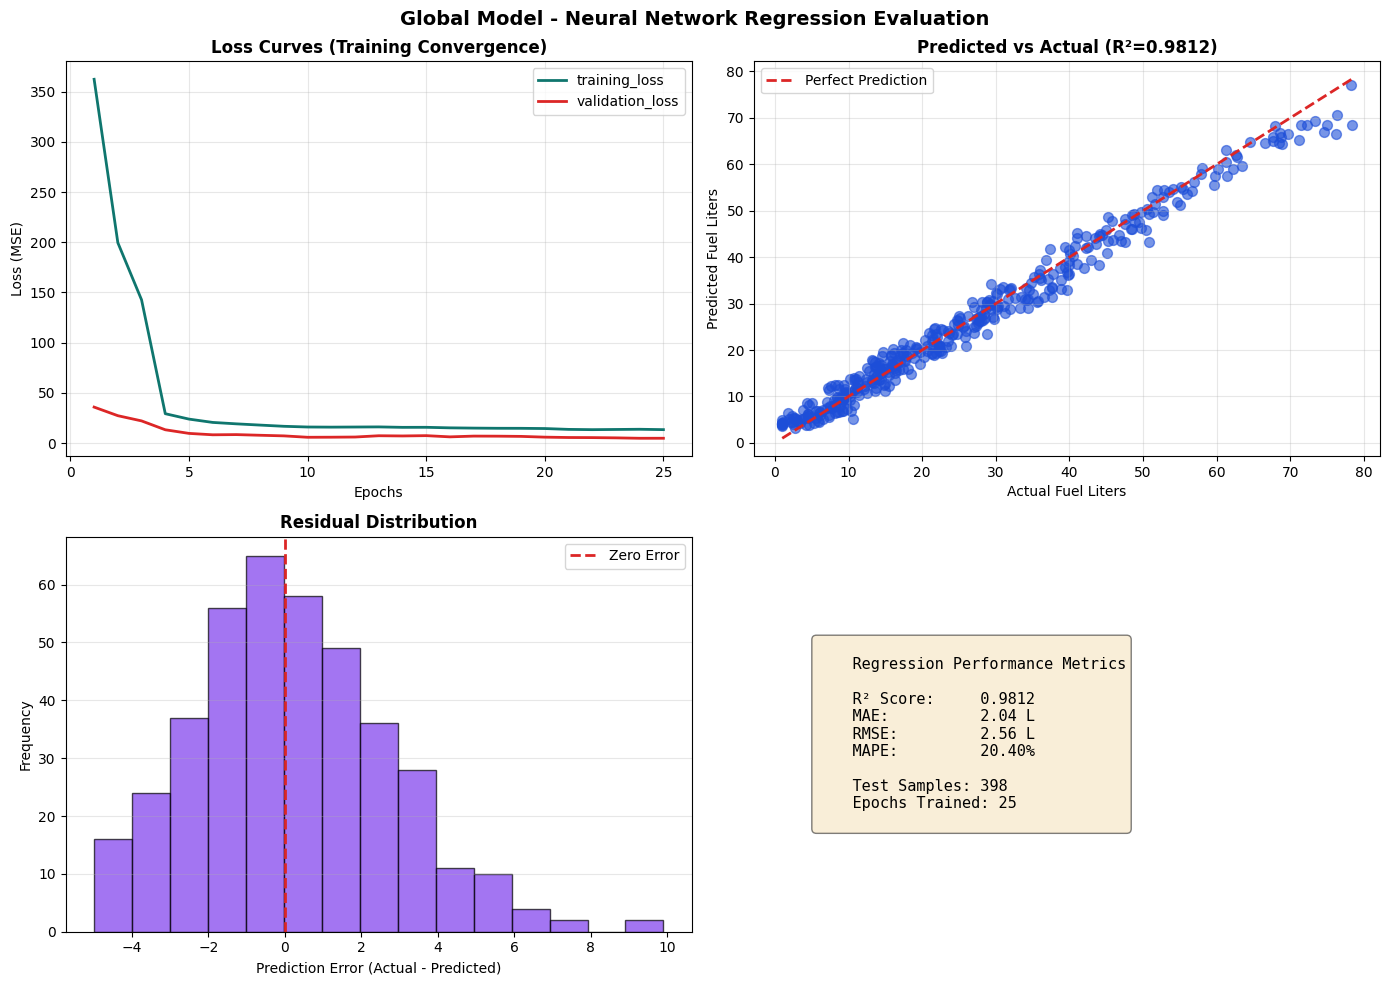


Saved neural network evaluation plots to: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\models\fishtripcost\global\best_model\reports\figures\neural_network_regression_evaluation.png


In [27]:
# ==============================
# NEURAL NETWORK EVALUATION & VISUALIZATION
# ==============================

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Setup figure directory if not already done
report_dir = target_dir / 'reports'
figure_dir = report_dir / 'figures'
figure_dir.mkdir(parents=True, exist_ok=True)

if history is None:
    print('Skipping graph generation: insufficient training data for neural network')
else:
    # Get predictions on test set
    y_pred_nn = nn_model.predict(X_test_scaled, verbose=0)
    y_pred_nn = y_pred_nn.flatten()
    
    # Calculate proper regression metrics
    nn_r2 = r2_score(y_test, y_pred_nn)
    nn_mae = mean_absolute_error(y_test, y_pred_nn)
    nn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_nn))
    nn_mape = np.mean(np.abs((y_test - y_pred_nn) / np.maximum(np.abs(y_test), 1e-9))) * 100
    
    print('[Neural Network Evaluation]')
    print(f'  R² Score: {nn_r2:.4f}')
    print(f'  MAE: {nn_mae:.2f}')
    print(f'  RMSE: {nn_rmse:.2f}')
    print(f'  MAPE: {nn_mape:.2f}%')
    
    # ==============================
    # PLOT 1: Loss Curves (Training Convergence)
    # PLOT 2: Predicted vs Actual (Regression Quality)
    # PLOT 3: Residuals (Error Distribution)
    # PLOT 4: Metrics Summary
    # ==============================
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Global Model - Neural Network Regression Evaluation', fontsize=14, fontweight='bold')
    
    epochs = range(1, len(history.history['loss']) + 1)
    
    # --- SUBPLOT 1: Training Loss Curves ---
    train_loss = pd.Series(history.history['loss']).rolling(3, min_periods=1).mean()
    axes[0, 0].plot(epochs, train_loss, label='training_loss', linewidth=2, color='#0f766e')
    
    if 'val_loss' in history.history:
        val_loss = pd.Series(history.history['val_loss']).rolling(3, min_periods=1).mean()
        axes[0, 0].plot(epochs, val_loss, label='validation_loss', linewidth=2, color='#dc2626')
    
    axes[0, 0].set_title('Loss Curves (Training Convergence)', fontweight='bold')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Loss (MSE)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # --- SUBPLOT 2: Predicted vs Actual (CRITICAL FOR REGRESSION) ---
    min_val = min(y_test.min(), y_pred_nn.min())
    max_val = max(y_test.max(), y_pred_nn.max())
    
    axes[0, 1].scatter(y_test, y_pred_nn, alpha=0.6, s=50, color='#1d4ed8')
    axes[0, 1].plot([min_val, max_val], [min_val, max_val], '--', color='#dc2626', linewidth=2, label='Perfect Prediction')
    axes[0, 1].set_title(f'Predicted vs Actual (R²={nn_r2:.4f})', fontweight='bold')
    axes[0, 1].set_xlabel('Actual Fuel Liters')
    axes[0, 1].set_ylabel('Predicted Fuel Liters')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # --- SUBPLOT 3: Residual Distribution ---
    residuals = y_test.values - y_pred_nn
    residual_bins = max(5, min(15, len(y_test) // 2))
    axes[1, 0].hist(residuals, bins=residual_bins, color='#7c3aed', alpha=0.7, edgecolor='black')
    axes[1, 0].axvline(0, color='#dc2626', linestyle='--', linewidth=2, label='Zero Error')
    axes[1, 0].set_title('Residual Distribution', fontweight='bold')
    axes[1, 0].set_xlabel('Prediction Error (Actual - Predicted)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # --- SUBPLOT 4: Regression Metrics Summary ---
    metrics_text = f'''
    Regression Performance Metrics
    
    R² Score:     {nn_r2:.4f}
    MAE:          {nn_mae:.2f} L
    RMSE:         {nn_rmse:.2f} L
    MAPE:         {nn_mape:.2f}%
    
    Test Samples: {len(y_test)}
    Epochs Trained: {len(history.history['loss'])}
    '''
    
    axes[1, 1].text(0.1, 0.5, metrics_text, fontsize=11, verticalalignment='center',
                    family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Save the figure
    nn_figure_path = figure_dir / 'neural_network_regression_evaluation.png'
    fig.savefig(nn_figure_path, dpi=160, bbox_inches='tight')
    print(f'\nSaved neural network evaluation plots to: {nn_figure_path}')

In [28]:
# ==============================
# SAVE NEURAL NETWORK MODEL
# ==============================

if history is None:
    print('Skipping neural network model save: insufficient training data')
else:
    # Save the neural network model as pickle directly in model storage folder
    nn_model_path = target_dir / 'global_neural_network_model.pkl'
    import pickle
    with open(nn_model_path, 'wb') as f:
        pickle.dump(nn_model, f)

    # Save model metrics
    nn_metrics = {
        'model_type': 'neural_network',
        'model_scope': 'global',
        'r2_score': float(nn_r2),
        'mae': float(nn_mae),
        'rmse': float(nn_rmse),
        'mape': float(nn_mape),
        'test_samples': int(len(y_test)),
        'epochs_trained': int(len(history.history['loss']))
    }

    nn_metrics_file = target_dir / 'neural_network_metrics.json'
    nn_metrics_file.write_text(json.dumps(nn_metrics, indent=2), encoding='utf-8')

    print(f'Saved neural network model to: {nn_model_path}')
    print(f'Saved neural network metrics to: {nn_metrics_file}')

Saved neural network model to: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\models\fishtripcost\global\best_model\global_neural_network_model.pkl
Saved neural network metrics to: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\models\fishtripcost\global\best_model\neural_network_metrics.json


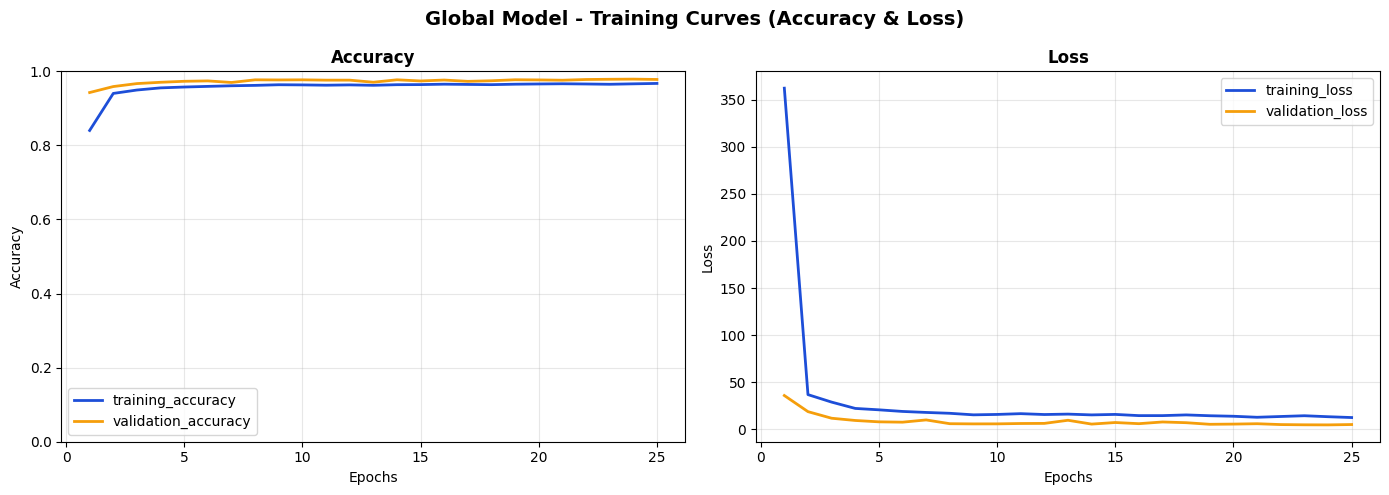

Saved simple accuracy & loss graphs to: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\models\fishtripcost\global\best_model\reports\figures\training_accuracy_loss.png


In [29]:
# ==============================
# SIMPLE 2-PANEL: TRAINING CURVES (Quick Overview)
# ==============================

if history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Global Model - Training Curves (Accuracy & Loss)', fontsize=14, fontweight='bold')
    
    epochs = range(1, len(history.history['loss']) + 1)
    y_train_max = y_train.max()
    
    # --- LEFT: Accuracy ---
    train_accuracy = 1.0 - (np.array(history.history['mae']) / y_train_max)
    train_accuracy = np.clip(train_accuracy, 0, 1)
    val_accuracy = 1.0 - (np.array(history.history['val_mae']) / y_train_max)
    val_accuracy = np.clip(val_accuracy, 0, 1)
    
    axes[0].plot(epochs, train_accuracy, label='training_accuracy', linewidth=2, color='#1d4ed8')
    axes[0].plot(epochs, val_accuracy, label='validation_accuracy', linewidth=2, color='#f59e0b')
    axes[0].set_title('Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim(0, 1)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # --- RIGHT: Loss ---
    axes[1].plot(epochs, history.history['loss'], label='training_loss', linewidth=2, color='#1d4ed8')
    axes[1].plot(epochs, history.history['val_loss'], label='validation_loss', linewidth=2, color='#f59e0b')
    axes[1].set_title('Loss', fontweight='bold')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Save the figure
    simple_figure_path = figure_dir / 'training_accuracy_loss.png'
    fig.savefig(simple_figure_path, dpi=160, bbox_inches='tight')
    print(f'Saved simple accuracy & loss graphs to: {simple_figure_path}')